# Chemical Space Exploration — CYP450 Direct Inhibition Data

Answers four feasibility questions for the cluster-based split design planned for the
core decomposition analysis (a later notebook): how diverse is the chemical space, how
does potency spread relate to known CYP-isoform structural determinants, how
discontinuous is the SAR (activity cliffs), and are there broad chemical series or is
the space too fragmented for scaffold/cluster-based splitting to matter.

**This notebook does not build the cluster split itself** — it only characterizes
whether that split is likely to differ meaningfully from a random split, and flags
risks to that design where the data suggests them.

**This notebook does NOT do:** feature/descriptor generation for modelling, CV fold
construction, or modelling. Loads only the curated files built in
`01_data_curation.ipynb` — `data/processed/train_inhibition_curated.csv` and
`test_blinded_curated.csv` — no raw files are touched here.

Per `CLAUDE.md`: row counts are logged at each stage; fingerprint/similarity/SALI logic
lives in `src/features.py`, not duplicated inline; every modelling-adjacent decision not
settled by the task brief was flagged and confirmed before proceeding (see the three
flagged decisions noted inline in Sections 3 and 4).

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import mols2grid

from src.features import (
    ecfp4_fingerprints,
    pairwise_tanimoto_matrix,
    nearest_neighbor_similarity,
    compute_sali,
    isoform_structural_descriptors,
    bemis_murcko_scaffold,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

PROCESSED = 'data/processed'  # relative to repo root -- run this notebook with cwd = repo root
ISOFORMS = ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']
PIC50_COLS = {iso: f'{iso}_pIC50_direct_inhibition' for iso in ISOFORMS}
ISO_COLOR = {'CYP1A2': 'tab:blue', 'CYP2C9': 'tab:orange', 'CYP2D6': 'tab:green', 'CYP3A4': 'tab:red'}

## 0. Load curated data and confirm row counts

Per `CLAUDE.md`, row counts are logged before any computation, and re-confirmed against
the figures already verified in `00_schema_audit.ipynb` / `01_data_curation.ipynb`
rather than assumed.

In [2]:
train = pd.read_csv(f'{PROCESSED}/train_inhibition_curated.csv')
test = pd.read_csv(f'{PROCESSED}/test_blinded_curated.csv')

print('train_inhibition_curated.csv shape:', train.shape)
print('test_blinded_curated.csv shape:', test.shape)
print()
print('per-isoform non-null pIC50 counts (train):')
for iso in ISOFORMS:
    n = train[PIC50_COLS[iso]].notna().sum()
    print(f'  {iso}: {n}')

train_inhibition_curated.csv shape: (4905, 20)
test_blinded_curated.csv shape: (750, 4)

per-isoform non-null pIC50 counts (train):
  CYP1A2: 1412
  CYP2C9: 1285
  CYP2D6: 1493
  CYP3A4: 2335


Matches `01_data_curation.ipynb` exactly: 4,905 train rows / 750 test rows, and the same
per-isoform counts verified there against the schema audit (CYP1A2 1,412 / CYP2C9 1,285
/ CYP2D6 1,493 / CYP3A4 2,335). This notebook does not filter or drop any rows at any
stage — every table below is either the full curated set or an isoform subset defined
purely by non-null pIC50, never a quality-based exclusion.

## Fingerprint settings — ECFP4, chirality off

All similarity work in this notebook (diversity, nearest-neighbour, SALI) uses **ECFP4**
(Morgan fingerprints, radius 2 / diameter 4, 2048-bit) with **`includeChirality=False`**,
implemented once as `ecfp4_fingerprints()` in `src/features.py` — not duplicated inline,
per `CLAUDE.md`'s shared-module rule.

**Chirality is off by default here.** This is a reasonable starting point, not yet
tested either way on this data — a controlled sensitivity check (chirality on vs. off)
is deferred to a later notebook, once a baseline model exists to test it against. One
direct consequence of this choice shows up in Section 4: two compounds that are pure
stereoisomers of each other are **fingerprint-identical** under this setting, which
means a real stereochemistry-driven potency difference between them can look
indistinguishable from a fingerprint artefact unless checked separately — done via
InChIKey comparison in Section 4c.

In [3]:
train_fps = ecfp4_fingerprints(train['canonical_smiles'].tolist())
test_fps = ecfp4_fingerprints(test['canonical_smiles'].tolist())

n_fail_train = sum(fp is None for fp in train_fps)
n_fail_test = sum(fp is None for fp in test_fps)
print(f'train: {len(train_fps)} fingerprints generated, {n_fail_train} parse failures')
print(f'test:  {len(test_fps)} fingerprints generated, {n_fail_test} parse failures')

train: 4905 fingerprints generated, 0 parse failures
test:  750 fingerprints generated, 0 parse failures


Zero parse failures in either set — expected, since `canonical_smiles` was already
validated by successfully parsing in `01_data_curation.ipynb`.

## 1. Chemical diversity

Pairwise and nearest-neighbour (NN) Tanimoto similarity, computed exhaustively (no
subsampling — all pair counts here are small enough, up to ~2.7M pairs for the largest
isoform subset, to compute in full) — overall across the full training set, then
separately per isoform subset (non-null pIC50 for that isoform only).

In [4]:
def pairwise_and_nn_stats(fps):
    matrix = pairwise_tanimoto_matrix(fps)
    iu = np.triu_indices_from(matrix, k=1)
    pairwise = matrix[iu]
    nn = nearest_neighbor_similarity(fps, fps, exclude_self_index=True)
    return pairwise, nn

overall_pairwise, overall_nn = pairwise_and_nn_stats(train_fps)
print(f'overall (n={len(train_fps)}): {len(overall_pairwise)} pairs')
print(f'  pairwise Tanimoto  -- mean {overall_pairwise.mean():.3f}, median {np.median(overall_pairwise):.3f}')
print(f'  nearest-neighbour  -- mean {overall_nn.mean():.3f}, median {np.median(overall_nn):.3f}')

iso_pairwise, iso_nn, iso_n = {}, {}, {}
print()
print('per isoform:')
for iso in ISOFORMS:
    mask = train[PIC50_COLS[iso]].notna().values
    idx = np.where(mask)[0]
    sub_fps = [train_fps[i] for i in idx]
    pw, nn = pairwise_and_nn_stats(sub_fps)
    iso_pairwise[iso], iso_nn[iso], iso_n[iso] = pw, nn, len(idx)
    print(f'  {iso} (n={len(idx)}): pairwise mean {pw.mean():.3f} / median {np.median(pw):.3f}'
          f'  |  NN mean {nn.mean():.3f} / median {np.median(nn):.3f}')

overall (n=4905): 12027060 pairs
  pairwise Tanimoto  -- mean 0.134, median 0.131
  nearest-neighbour  -- mean 0.464, median 0.450

per isoform:


  CYP1A2 (n=1412): pairwise mean 0.130 / median 0.126  |  NN mean 0.403 / median 0.400


  CYP2C9 (n=1285): pairwise mean 0.142 / median 0.139  |  NN mean 0.445 / median 0.441


  CYP2D6 (n=1493): pairwise mean 0.128 / median 0.125  |  NN mean 0.375 / median 0.351


  CYP3A4 (n=2335): pairwise mean 0.139 / median 0.136  |  NN mean 0.488 / median 0.458


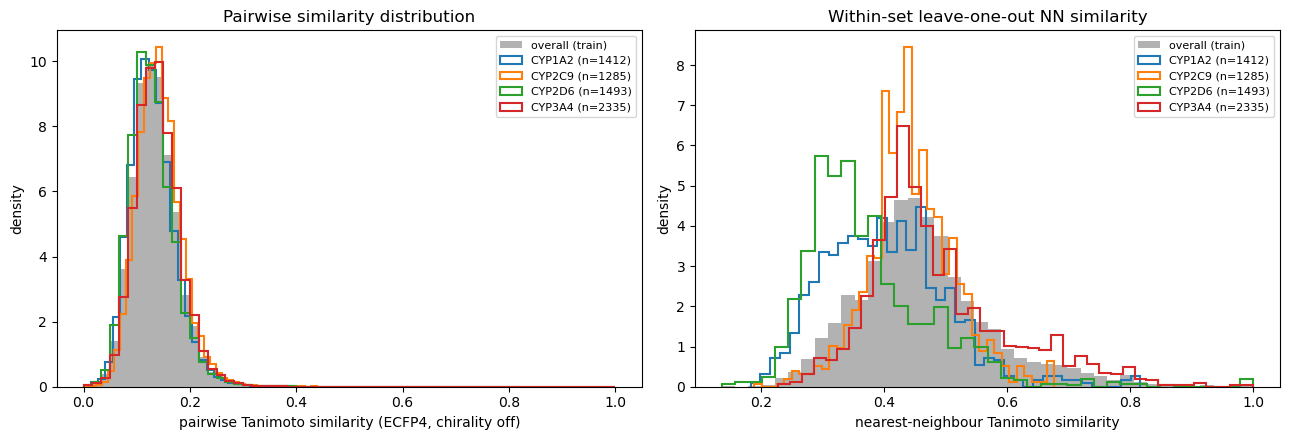

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(overall_pairwise, bins=60, color='0.5', alpha=0.6, density=True, label='overall (train)')
for iso in ISOFORMS:
    axes[0].hist(iso_pairwise[iso], bins=60, histtype='step', density=True,
                 color=ISO_COLOR[iso], linewidth=1.5, label=f'{iso} (n={iso_n[iso]})')
axes[0].set_xlabel('pairwise Tanimoto similarity (ECFP4, chirality off)')
axes[0].set_ylabel('density')
axes[0].set_title('Pairwise similarity distribution')
axes[0].legend(fontsize=8)

axes[1].hist(overall_nn, bins=40, color='0.5', alpha=0.6, density=True, label='overall (train)')
for iso in ISOFORMS:
    axes[1].hist(iso_nn[iso], bins=40, histtype='step', density=True,
                 color=ISO_COLOR[iso], linewidth=1.5, label=f'{iso} (n={iso_n[iso]})')
axes[1].set_xlabel('nearest-neighbour Tanimoto similarity')
axes[1].set_ylabel('density')
axes[1].set_title('Within-set leave-one-out NN similarity')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**What this shows:** pairwise similarity is low and tightly concentrated near 0.1–0.15
for every isoform subset and overall — the large majority of compound pairs in this
dataset share little substructure under ECFP4. The NN distribution is much broader
(median ~0.35–0.49 depending on isoform), i.e. most compounds do have *some* moderately
similar neighbour, but pairs approaching high similarity (>0.4) are rare (quantified
directly in Section 4). Both patterns point the same way: broad coverage of chemical
space with few large, tightly-related families — consistent with the scaffold
fragmentation found directly in Section 5.

**Sample-size flag:** CYP2C9 (n=1,285) is the smallest isoform subset and CYP3A4
(n=2,335) the largest — nearly double. A larger candidate pool mechanically raises the
chance of finding *some* moderately close neighbour purely by having more candidates to
compare against, independent of whether that isoform's true chemical space is denser.
CYP3A4 does show the highest NN mean (0.488) of the four, consistent with that effect.
But the ordering isn't fully explained by sample size alone: CYP2C9, despite being the
*smallest* subset, has a higher NN mean (0.445) than CYP2D6 (0.375, n=1,493 — larger than
CYP2C9). If NN similarity were driven purely by pool size, CYP2D6 should exceed CYP2C9.
It doesn't, which suggests genuine differences in per-isoform chemical space density are
also contributing — but the two effects can't be cleanly separated with this data alone,
so the isoform NN differences reported above should be read as suggestive, not as a
clean measurement of "true" per-isoform diversity.

## 2. Test→train nearest-neighbour similarity

Test→train NN: for each of the 750 test compounds, the max Tanimoto similarity to any
of the 4,905 training compounds. Train LOO NN: for each training compound, the max
Tanimoto similarity to any *other* training compound (leave-one-out, self excluded).
Both computed exhaustively.

This is the **first measurement of this comparison** on the curated real data — not a
confirmation or re-verification of a prior result. Reported here on its own terms.

In [6]:
test_to_train_nn = nearest_neighbor_similarity(test_fps, train_fps, exclude_self_index=False)
train_loo_nn = overall_nn  # already computed in Section 1 (full train, leave-one-out)

print(f'test->train NN (n={len(test_to_train_nn)}): mean {test_to_train_nn.mean():.3f}, median {np.median(test_to_train_nn):.3f}, '
      f'min {test_to_train_nn.min():.3f}, max {test_to_train_nn.max():.3f}')
print(f'train LOO NN  (n={len(train_loo_nn)}): mean {train_loo_nn.mean():.3f}, median {np.median(train_loo_nn):.3f}, '
      f'min {train_loo_nn.min():.3f}, max {train_loo_nn.max():.3f}')

u_stat, p_value = stats.mannwhitneyu(test_to_train_nn, train_loo_nn)
print()
print(f'Mann-Whitney U test (test->train NN vs. train LOO NN): U={u_stat:.1f}, p={p_value:.3e}')

test->train NN (n=750): mean 0.598, median 0.587, min 0.318, max 0.952
train LOO NN  (n=4905): mean 0.464, median 0.450, min 0.136, max 1.000

Mann-Whitney U test (test->train NN vs. train LOO NN): U=3174582.5, p=1.323e-225


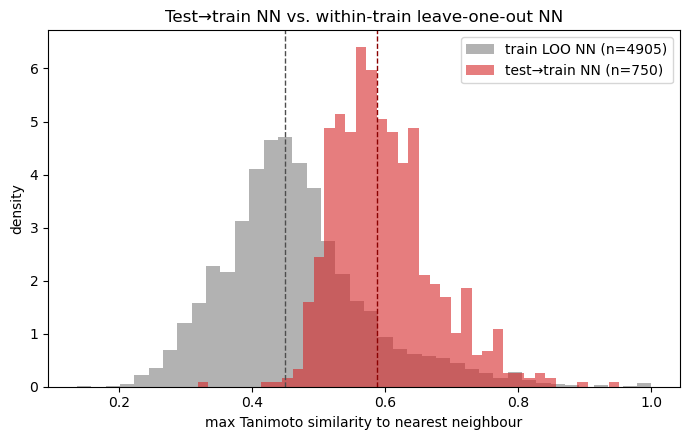

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(train_loo_nn, bins=40, density=True, alpha=0.6, color='0.5', label=f'train LOO NN (n={len(train_loo_nn)})')
ax.hist(test_to_train_nn, bins=40, density=True, alpha=0.6, color='tab:red', label=f'test→train NN (n={len(test_to_train_nn)})')
ax.axvline(np.median(train_loo_nn), color='0.3', linestyle='--', linewidth=1)
ax.axvline(np.median(test_to_train_nn), color='darkred', linestyle='--', linewidth=1)
ax.set_xlabel('max Tanimoto similarity to nearest neighbour')
ax.set_ylabel('density')
ax.set_title('Test→train NN vs. within-train leave-one-out NN')
ax.legend()
plt.tight_layout()
plt.show()

**What this shows, stated plainly:** on this measurement, test compounds are closer to
their nearest training-set neighbour (median max-Tanimoto 0.587) than training compounds
are to *their* nearest training-set neighbour (median 0.450) — a large, highly
significant difference (Mann-Whitney p ≈ 1.3×10⁻²²⁵). This is the opposite of "the test
set is a harder, more novel set of compounds relative to train" — under this
chirality-off ECFP4 similarity metric, test compounds are *more* redundant with training
data than training data is with itself.

**Implication for the cluster-based split decomposition:** if the goal of a cluster-
based split is to measure how much performance degrades when a model is evaluated on
compounds without close training neighbours, this result suggests that loss of
nearest-neighbour support may be **less severe than assumed** — at least relative to
the real blinded test set, which does not appear to have been constructed to be
maximally dissimilar from train. This is a first observation on real data, not a final
verdict; it doesn't say what a *constructed* cluster split would look like, only that the
real test set isn't already exhibiting the kind of separation such a split is meant to
simulate.

**Isoform caveat:** this pooled test→train number mixes isoforms that played different
roles in how the real test set was built — CYP1A2, CYP2C9, and CYP3A4 compounds seeded
the test set's construction, CYP2D6 did not. `TEST-BLINDED.csv` carries no label columns
at all, so the 750 test compounds can't be split by isoform to check this directly; the
pooled number above may not represent CYP2D6 as well as it represents the other three.

## 3. Potency spread and CYP-specific structural determinants

pIC50 distributions per isoform, then simple Pearson correlations against the
isoform-specific structural descriptors from Kiani & Jabeen (2019):

- **CYP1A2:** HBA count, molecular weight, stereocenter count, HBD+HBA combined
- **CYP2C9:** molecular weight, HBD, logD
- **CYP2D6:** total charge, HBD, HBA, ring count, stereocenter count, molecular weight, logP
- **CYP3A4:** molecular weight, vsa_acc (H-bond-acceptor surface area)

**Two descriptors flagged and confirmed before computing, not silently picked:**
RDKit has no native **logD** calculator (logD is pH/ionization-state-dependent; RDKit
only provides logP, which is not) and no dedicated logD tool is available in this
environment — `logd_proxy` below uses Crippen `MolLogP` as a stated approximation, not a
true logD. Similarly, RDKit has no descriptor named **`vsa_acc`** (that name is
QikProp/Schrödinger-specific, "accessible surface area of H-bond-acceptor atoms") —
`vsa_acc_proxy` below sums `PEOE_VSA1`+`PEOE_VSA2` (surface area of the atoms with the
most negative partial charges, i.e. O/N-type acceptor character), the standard
open-source stand-in. Both proxies are implemented in `isoform_structural_descriptors()`
in `src/features.py`, labeled `_proxy` throughout so they're never confused with the
real thing downstream.

In [8]:
desc_rows = [isoform_structural_descriptors(s) for s in train['canonical_smiles']]
desc_df = pd.DataFrame(desc_rows)
desc_df['hbd_hba_combined'] = desc_df['hbd'] + desc_df['hba']
train_desc = pd.concat([train.reset_index(drop=True), desc_df], axis=1)

print('descriptor rows:', len(desc_df), '(matches train row count:', len(desc_df) == len(train), ')')
desc_df.describe()

descriptor rows: 4905 (matches train row count: True )


,mol_wt,hba,hbd,ring_count,stereocenter_count,formal_charge,logp,logd_proxy,vsa_acc_proxy,hbd_hba_combined
count,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000,4905.000000
mean,346.583928,4.511519,1.243017,3.362080,0.688481,0.000204,2.792475,2.792475,18.647935,5.754536
std,50.509630,1.453998,0.900236,0.864723,0.934869,0.065438,1.076987,1.076987,6.948595,1.628813
min,75.067000,0.000000,0.000000,0.000000,0.000000,-1.000000,-3.358300,-3.358300,0.000000,0.000000
25%,318.446000,4.000000,1.000000,3.000000,0.000000,0.000000,2.145720,2.145720,14.528477,5.000000
50%,342.798000,4.000000,1.000000,3.000000,0.000000,0.000000,2.806200,2.806200,19.472317,6.000000
75%,370.428000,5.000000,2.000000,4.000000,1.000000,0.000000,3.443900,3.443900,24.222924,7.000000
max,973.675000,13.000000,8.000000,9.000000,14.000000,1.000000,13.585800,13.585800,62.745886,18.000000


CYP1A2: mean=4.96, median=5.13, std=1.03, skew=-0.83, min=1.91, max=7.95
CYP2C9: mean=4.58, median=4.62, std=0.78, skew=-0.34, min=2.10, max=7.47
CYP2D6: mean=4.78, median=4.73, std=0.92, skew=-0.67, min=1.95, max=7.53
CYP3A4: mean=4.10, median=4.27, std=1.09, skew=-0.35, min=1.91, max=7.19


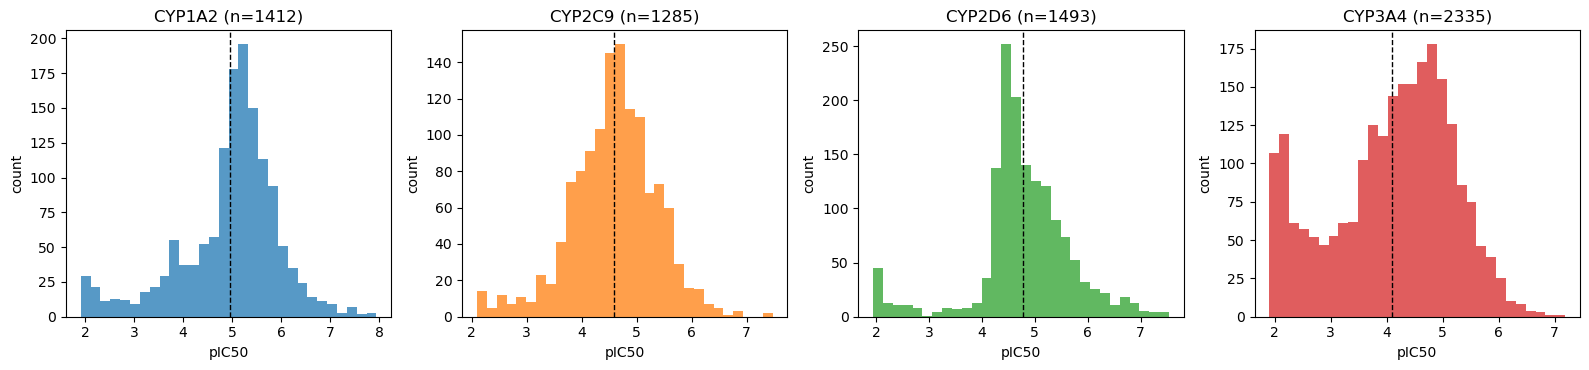

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=False)
for ax, iso in zip(axes, ISOFORMS):
    vals = train[PIC50_COLS[iso]].dropna()
    ax.hist(vals, bins=30, color=ISO_COLOR[iso], alpha=0.75)
    ax.axvline(vals.mean(), color='k', linestyle='--', linewidth=1)
    ax.set_title(f'{iso} (n={len(vals)})')
    ax.set_xlabel('pIC50')
    ax.set_ylabel('count')
    print(f'{iso}: mean={vals.mean():.2f}, median={vals.median():.2f}, std={vals.std():.2f}, '
          f'skew={vals.skew():.2f}, min={vals.min():.2f}, max={vals.max():.2f}')
plt.tight_layout()
plt.show()

All four isoforms show a roughly unimodal, mildly right- or left-skewed pIC50
distribution spanning the same ~2–8 range noted in the schema audit, with means
clustered around 4.5–5.5. Nothing structurally unusual beyond what was already
established — this is the "go further" view (per-isoform shape, skew, spread) referenced
in the task brief, building on the basic version in `00_schema_audit.ipynb`.

In [10]:
isoform_descriptor_map = {
    'CYP1A2': ['hba', 'mol_wt', 'stereocenter_count', 'hbd_hba_combined'],
    'CYP2C9': ['mol_wt', 'hbd', 'logd_proxy'],
    'CYP2D6': ['formal_charge', 'hbd', 'hba', 'ring_count', 'stereocenter_count', 'mol_wt', 'logp'],
    'CYP3A4': ['mol_wt', 'vsa_acc_proxy'],
}

corr_rows = []
for iso, descriptors in isoform_descriptor_map.items():
    col = PIC50_COLS[iso]
    sub = train_desc[train_desc[col].notna()]
    for d in descriptors:
        r, p = stats.pearsonr(sub[d], sub[col])
        corr_rows.append({'isoform': iso, 'descriptor': d, 'n': len(sub), 'pearson_r': round(r, 3), 'p_value': p})

corr_df = pd.DataFrame(corr_rows)
corr_df

,isoform,descriptor,n,pearson_r,p_value
0,CYP1A2,hba,1412,-0.070,8.278855e-03
1,CYP1A2,mol_wt,1412,-0.125,2.297890e-06
2,CYP1A2,stereocenter_count,1412,-0.087,1.069503e-03
3,CYP1A2,hbd_hba_combined,1412,-0.083,1.699859e-03
4,CYP2C9,mol_wt,1285,0.246,3.330444e-19
5,CYP2C9,hbd,1285,0.013,6.398589e-01
6,CYP2C9,logd_proxy,1285,0.467,1.271111e-70
7,CYP2D6,formal_charge,1493,0.027,2.913836e-01
8,CYP2D6,hbd,1493,-0.081,1.637744e-03
9,CYP2D6,hba,1493,-0.048,6.299662e-02


**What this shows:** correlations are weak across almost every descriptor — CYP1A2's
strongest is HBA/HBD-combined-adjacent at |r|≈0.13 (mol_wt), CYP2D6's are all |r|<0.09
including logP at essentially zero (r=0.002, p=0.94), and CYP3A4 sits at |r|≈0.24–0.29.
The one moderate correlation is CYP2C9 vs. `logd_proxy` (r=0.467, p≈1.3×10⁻⁷⁰) — still
far from strong, but the largest in this table by a clear margin.

Beck et al. (2021) found only weak correlations between MW/logP and IC50 in the
literature generally, and **no significant relationship at all for CYP2D6** — the
near-zero CYP2D6/logP result here (r=0.002) matches that finding directly. A weak
correlation here is consistent with prior literature, **not evidence of a data
problem**, and none of these weak-to-moderate correlations should be over-interpreted as
a standalone finding — they're a sanity check against known structural determinants, not
a discovery.

## 4. SAR discontinuity — activity cliffs (SALI method)

SALI (Structure-Activity Landscape Index, Guha & Van Drie 2008): `SALI_ij = |ΔpIC50| /
(1 - Tanimoto_ij)`, computed per isoform independently (never unioning cliff sets across
isoforms) using ECFP4 with chirality off, via `compute_sali()` in `src/features.py`.

**Cliff thresholds flagged and confirmed before computing:** the task brief doesn't fix
a similarity cutoff for "similar pairs" or a ΔpIC50 cutoff for "cliff" — both were
confirmed directly: **Tanimoto ≥0.9** to define a similar pair, **ΔpIC50 ≥1** (10-fold
potency difference) to call a similar pair a cliff, following Van Tilborg et al.'s
consensus similarity threshold. This is the adopted primary threshold below (4a). Two
labeled sensitivity checks follow it (4d, 4e) rather than silently substituting a
different threshold, per the same confirmation.

### 4a. Primary result — Tanimoto ≥0.9, ΔpIC50 ≥1

**Implementation note surfaced during execution, not silently absorbed:** `compute_sali`
correctly excludes pairs with similarity exactly 1.0 from its SALI score (`SALI = ΔpIC50
/ (1 - similarity)` is undefined — division by zero — for a fingerprint-identical pair).
But at a 0.9 threshold, fingerprint-identical pairs turn out to be common enough among
the few "similar" pairs that exist that simply reading `compute_sali`'s output alone
would silently drop most of the similar-pair population for some isoforms. Handled
below by computing the identical-fingerprint pairs explicitly (cliff status is still
well-defined there via the ΔpIC50 criterion directly, even though a SALI score isn't),
and reporting the two subsets combined.

In [11]:
SIMILARITY_THRESHOLD_PRIMARY = 0.9
CLIFF_THRESHOLD = 1.0

def similar_pairs_with_identical(iso, threshold):
    # All pairs with similarity >= threshold for one isoform, split into the
    # SALI-computable subset (threshold <= sim < 1.0, from compute_sali) and the
    # fingerprint-identical subset (sim == 1.0, excluded from compute_sali by its
    # div-by-zero guard but handled here directly via the delta_activity criterion).
    col = PIC50_COLS[iso]
    mask = train[col].notna().values
    idx = np.where(mask)[0]
    sub_fps = [train_fps[i] for i in idx]
    sub_activities = train[col].values[idx]

    sali_df = compute_sali(sub_fps, sub_activities, threshold, CLIFF_THRESHOLD)

    matrix = pairwise_tanimoto_matrix(sub_fps)
    iu = np.triu_indices_from(matrix, k=1)
    exact_mask = matrix[iu] >= 1.0 - 1e-9
    ei, ej = iu[0][exact_mask], iu[1][exact_mask]
    identical_delta = np.abs(sub_activities[ei] - sub_activities[ej])
    identical_df = pd.DataFrame({
        'i': ei, 'j': ej, 'similarity': 1.0, 'delta_activity': identical_delta,
        'sali': np.inf, 'is_cliff': identical_delta >= CLIFF_THRESHOLD,
    })
    return sali_df, identical_df, idx

sali_090 = {}
for iso in ISOFORMS:
    sali_df, identical_df, idx = similar_pairs_with_identical(iso, SIMILARITY_THRESHOLD_PRIMARY)
    sali_090[iso] = (sali_df, identical_df, idx)
    n_similar = len(sali_df) + len(identical_df)
    n_cliff = int(sali_df['is_cliff'].sum()) + int(identical_df['is_cliff'].sum())
    if n_similar:
        pct = 100 * n_cliff / n_similar
        print(f'{iso}: {n_similar} similar pairs ({len(sali_df)} at 0.9<=sim<1.0, {len(identical_df)} at sim=1.0), '
              f'{n_cliff} cliffs, prevalence={pct:.1f}%')
    else:
        print(f'{iso}: 0 similar pairs (Tanimoto>=0.9) -- prevalence undefined')

CYP1A2: 0 similar pairs (Tanimoto>=0.9) -- prevalence undefined


CYP2C9: 0 similar pairs (Tanimoto>=0.9) -- prevalence undefined


CYP2D6: 3 similar pairs (0 at 0.9<=sim<1.0, 3 at sim=1.0), 1 cliffs, prevalence=33.3%


CYP3A4: 4 similar pairs (3 at 0.9<=sim<1.0, 1 at sim=1.0), 0 cliffs, prevalence=0.0%


**Stated plainly, this is the primary finding, not a failed computation:** at the
literature-anchored Tanimoto ≥0.9 threshold, "similar pairs" are extremely rare in this
dataset. CYP1A2 and CYP2C9 have **zero** pairs meeting the bar at all — cliff prevalence
is undefined, not zero, since there's no denominator. CYP2D6 has 3 similar pairs (1
cliff, 33.3%) and CYP3A4 has 4 (0 cliffs, 0.0%), out of roughly 1–2.7 million possible
pairs per isoform. This is itself a direct, concrete confirmation of the chemical-space
fragmentation already suggested by Section 1's diversity numbers and confirmed
structurally in Section 5's scaffold count — and it means the PXR reference-range
comparison (4–12% cliff propensity among similar pairs) is **not meaningfully computable
at this threshold** for 2 of the 4 isoforms, and rests on single-digit sample sizes for
the other 2. Notably, *all 3* of CYP2D6's similar pairs are fingerprint-identical
(sim=1.0) — investigated directly in 4c below.

### 4b. Visual inspection — all 0.9-threshold pairs

Only 7 pairs total across all isoforms at this threshold, so all of them are shown
(rather than a "top-N", per the task's "inspect the top-ranked cliff pairs" instruction —
with this few, "all" and "top-ranked" are the same set).

In [12]:
def pairs_to_grid_df(pairs_df, idx, col, label):
    sub = train.iloc[idx].reset_index(drop=True)
    rows = []
    for _, row in pairs_df.iterrows():
        i, j = int(row['i']), int(row['j'])
        for k in (i, j):
            m = sub.iloc[k]
            rows.append({
                'SMILES': m['canonical_smiles'],
                'Molecule_Name': m['Molecule_Name'],
                'pIC50': round(float(m[col]), 2),
                'pair_id': f"{sub.iloc[i]['Molecule_Name']}_{sub.iloc[j]['Molecule_Name']}",
                'similarity': round(float(row['similarity']), 3),
                'delta_pIC50': round(float(row['delta_activity']), 2),
                'sali': round(float(row['sali']), 2) if np.isfinite(row['sali']) else None,
                'set': label,
            })
    return pd.DataFrame(rows)

grid_090_frames = []
for iso in ['CYP2D6', 'CYP3A4']:  # the only isoforms with any pairs at this threshold
    sali_df, identical_df, idx = sali_090[iso]
    combined_df = pd.concat([sali_df, identical_df], ignore_index=True)
    if len(combined_df):
        grid_090_frames.append(pairs_to_grid_df(combined_df, idx, PIC50_COLS[iso], iso))
grid_090_df = pd.concat(grid_090_frames, ignore_index=True)
print(f'{len(grid_090_df)} molecules across {grid_090_df["pair_id"].nunique()} pairs')
mols2grid.display(grid_090_df, smiles_col='SMILES', subset=['img', 'Molecule_Name', 'set', 'pIC50'],
                   tooltip=['pair_id', 'similarity', 'delta_pIC50', 'sali'], n_cols=4)

14 molecules across 7 pairs


/var/folders/g2/8zyjglrn4c7dqmvyh0hq9p4m0000gn/T/ipykernel_34792/65460708.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([sali_df, identical_df], ignore_index=True)
/var/folders/g2/8zyjglrn4c7dqmvyh0hq9p4m0000gn/T/ipykernel_34792/65460708.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  grid_090_df = pd.concat(grid_090_frames, ignore_index=True)


### 4c. Chirality-artefact check

Per the task brief: check whether any of these near-identical-fingerprint pairs are
actually stereoisomers hidden by the chirality-off setting, by comparing InChIKey
**second blocks** (the stereochemical layer) for pairs whose **first block** (skeleton
connectivity) matches. Checked across all 7 pairs from 4b — both the SALI-computable
ones and the fingerprint-identical ones.

In [13]:
print('=== 0.9-threshold pairs: InChIKey block comparison ===')
for iso in ['CYP2D6', 'CYP3A4']:
    sali_df, identical_df, idx = sali_090[iso]
    sub = train.iloc[idx].reset_index(drop=True)
    combined_df = pd.concat([sali_df, identical_df], ignore_index=True)
    for _, row in combined_df.iterrows():
        i, j = int(row['i']), int(row['j'])
        mi, mj = sub.iloc[i], sub.iloc[j]
        block1_i, block1_j = mi['inchikey'].split('-')[0], mj['inchikey'].split('-')[0]
        block2_i, block2_j = mi['inchikey'].split('-')[1], mj['inchikey'].split('-')[1]
        same_skeleton = block1_i == block1_j
        flag = 'CHIRALITY ARTEFACT (same skeleton, different stereo layer)' if same_skeleton else 'genuine distinct compounds'
        print(f"{iso}: {mi['Molecule_Name']} vs {mj['Molecule_Name']}  sim={row['similarity']:.3f}  "
              f"delta_pIC50={row['delta_activity']:.2f}  -- {flag}")
        if same_skeleton:
            print(f"    block1: {block1_i} (match)   block2: {block2_i}  vs  {block2_j}")

=== 0.9-threshold pairs: InChIKey block comparison ===
CYP2D6: OCNT-0494161 vs OCNT-1911794  sim=1.000  delta_pIC50=2.56  -- CHIRALITY ARTEFACT (same skeleton, different stereo layer)
    block1: LOUPRKONTZGTKE (match)   block2: WZBLMQSHSA  vs  LHHVKLHASA
CYP2D6: OCNT-1965934 vs OCNT-2328651  sim=1.000  delta_pIC50=0.52  -- CHIRALITY ARTEFACT (same skeleton, different stereo layer)
    block1: LEBVLXFERQHONN (match)   block2: UHFFFAOYSA  vs  INIZCTEOSA
CYP2D6: OCNT-2328781 vs OCNT-2328911  sim=1.000  delta_pIC50=0.22  -- CHIRALITY ARTEFACT (same skeleton, different stereo layer)
    block1: MJIHNNLFOKEZEW (match)   block2: UHFFFAOYSA  vs  RUZDIDTESA
CYP3A4: OCNT-2395446 vs OCNT-2395749  sim=0.975  delta_pIC50=0.34  -- genuine distinct compounds
CYP3A4: OCNT-2395464 vs OCNT-2395789  sim=0.915  delta_pIC50=0.09  -- genuine distinct compounds
CYP3A4: OCNT-2395598 vs OCNT-2395602  sim=0.919  delta_pIC50=0.02  -- genuine distinct compounds
CYP3A4: OCNT-2395305 vs OCNT-2395406  sim=1.000  de

/var/folders/g2/8zyjglrn4c7dqmvyh0hq9p4m0000gn/T/ipykernel_34792/2112281370.py:5: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([sali_df, identical_df], ignore_index=True)


**Confirmed chirality artefacts:** all 3 of CYP2D6's 0.9-threshold pairs, and 1 of
CYP3A4's 4, share an identical InChIKey first block (same 2D connectivity) with
different second blocks (different stereo layer) — they are stereoisomer pairs that the
chirality-off fingerprint cannot distinguish, exactly the scenario flagged as a risk when
the fingerprint setting was chosen. These are exactly the 4 fingerprint-identical
(sim=1.0) pairs handled separately in 4a — unsurprising in hindsight, since two
compounds differing *only* in stereochemistry are guaranteed to be fingerprint-identical
once chirality is turned off, so this artefact type can only ever show up in that
subset. One of these (CYP2D6, `OCNT-0494161` vs `OCNT-1911794`) has a striking ΔpIC50 of
2.56 (~360-fold) between what this fingerprint treats as the same compound — almost
certainly a real, biologically meaningful stereochemistry-driven potency difference
(well precedented for CYP inhibition) rather than a data-quality problem, but it is
invisible to chirality-off similarity and would be mis-attributed to "the same compound
has inconsistent labels" rather than "these are different stereoisomers" without this
check. The remaining 3 of these 7 pairs (the SALI-computable CYP3A4 ones) are genuinely
distinct compounds with high but non-identical fingerprints, not artefacts.

A separate whole-training-set check (not limited to the 0.9-threshold pairs, or to any
one isoform) confirms these are the **only 4** same-skeleton/different-stereo pairs
across all 4,905 curated training compounds — nothing further to flag here beyond what's
already shown above.

### 4d. Sensitivity check — Tanimoto ≥0.8 (Dinh Pham et al.)

Exploratory context only, not a redefinition of the adopted 0.9/ΔpIC50≥1 threshold above.
Uses the same `similar_pairs_with_identical` helper from 4a, for the same reason: at 0.8
the fingerprint-identical pairs are still a non-trivial share of the (still small)
similar-pair population for some isoforms.

In [14]:
SIMILARITY_THRESHOLD_SENS1 = 0.8

sali_080 = {}
for iso in ISOFORMS:
    sali_df, identical_df, idx = similar_pairs_with_identical(iso, SIMILARITY_THRESHOLD_SENS1)
    sali_080[iso] = (sali_df, identical_df, idx)
    n_similar = len(sali_df) + len(identical_df)
    n_cliff = int(sali_df['is_cliff'].sum()) + int(identical_df['is_cliff'].sum())
    if n_similar:
        pct = 100 * n_cliff / n_similar
        print(f'{iso}: {n_similar} similar pairs ({len(sali_df)} at 0.8<=sim<1.0, {len(identical_df)} at sim=1.0), '
              f'{n_cliff} cliffs, prevalence={pct:.1f}%')
    else:
        print(f'{iso}: 0 similar pairs -- prevalence undefined')

CYP1A2: 3 similar pairs (3 at 0.8<=sim<1.0, 0 at sim=1.0), 1 cliffs, prevalence=33.3%


CYP2C9: 0 similar pairs -- prevalence undefined


CYP2D6: 7 similar pairs (4 at 0.8<=sim<1.0, 3 at sim=1.0), 2 cliffs, prevalence=28.6%


CYP3A4: 23 similar pairs (22 at 0.8<=sim<1.0, 1 at sim=1.0), 3 cliffs, prevalence=13.0%


Still small samples (0–23 similar pairs per isoform) — CYP2C9 remains exactly empty even
at 0.8. Where a prevalence is computable at all (CYP1A2 33%, CYP2D6 29%, CYP3A4 13%),
every value sits at or well above the PXR reference range, but on samples this small
(1/3, 2/7, 3/23 cliffs) the confidence interval on each percentage is wide enough that no
strong conclusion should be drawn from 0.8 alone. Per the same reasoning as 4a — this is
still too sparse a sample to treat as a stable estimate, which is why a further check at
a lower threshold follows.

### 4e. Final check — Tanimoto ≥0.4

A lower, more permissive "similar pair" bar, giving samples large enough (555–3,226
pairs per isoform) to treat the resulting prevalence as a stable estimate for this
dataset. Uses `compute_sali` directly (not the 4a/4d helper) — at this sample size the
handful of fingerprint-identical pairs excluded by `compute_sali`'s div-by-zero guard
(4 total across the whole dataset, all already inspected explicitly in 4c) shift the
CYP2D6/CYP3A4 counts by at most 1 pair, changing prevalence by <0.1 percentage point —
immaterial here, unlike at the 0.9/0.8 thresholds where they were a large share of a
tiny population.

In [15]:
SIMILARITY_THRESHOLD_SENS2 = 0.4

sali_040 = {}
summary_rows = []
for iso in ISOFORMS:
    col = PIC50_COLS[iso]
    mask = train[col].notna().values
    idx = np.where(mask)[0]
    sub_fps = [train_fps[i] for i in idx]
    sub_activities = train[col].values[idx]
    sali_df = compute_sali(sub_fps, sub_activities, SIMILARITY_THRESHOLD_SENS2, CLIFF_THRESHOLD)
    sali_040[iso] = (sali_df, idx)
    n_similar = len(sali_df)
    n_cliff = int(sali_df['is_cliff'].sum())
    pct = 100 * n_cliff / n_similar
    summary_rows.append({'isoform': iso, 'n_similar_pairs': n_similar, 'n_cliffs': n_cliff, 'cliff_prevalence_%': round(pct, 1)})
    print(f'{iso}: {n_similar} similar pairs, {n_cliff} cliffs, prevalence={pct:.1f}%')

sali_040_summary = pd.DataFrame(summary_rows)
print()
print('PXR reference range (comparable OpenADMET challenge): 4-12% cliff propensity among similar pairs')
sali_040_summary

CYP1A2: 555 similar pairs, 247 cliffs, prevalence=44.5%


CYP2C9: 600 similar pairs, 222 cliffs, prevalence=37.0%


CYP2D6: 582 similar pairs, 170 cliffs, prevalence=29.2%


CYP3A4: 3226 similar pairs, 1345 cliffs, prevalence=41.7%

PXR reference range (comparable OpenADMET challenge): 4-12% cliff propensity among similar pairs


,isoform,n_similar_pairs,n_cliffs,cliff_prevalence_%
0,CYP1A2,555,247,44.5
1,CYP2C9,600,222,37.0
2,CYP2D6,582,170,29.2
3,CYP3A4,3226,1345,41.7


**What this shows:** with an adequately sized sample, cliff prevalence in this dataset
(29–45% across the four isoforms) is **consistently and substantially higher** than the
PXR reference range (4–12%) — not close to it, and not just one isoform running high.
This pattern holds at both thresholds where a stable-ish estimate exists (0.8's 14–33%,
0.4's 29–45%), so it isn't an artefact of the 0.4 cutoff specifically.

This should be stated plainly as what the data shows, with one methodological caveat:
different SALI studies define "similar" and "cliff" differently (similarity metric,
fingerprint, and ΔActivity cutoff all vary across the literature), so this is a
sanity-check anchor rather than a strictly apples-to-apples benchmark, exactly as the
task brief frames it. Taken at face value, though, it suggests the CYP direct-inhibition
SAR in this dataset is locally more discontinuous than the PXR comparison case — small
structural changes are associated with large potency swings more often here.

### 4f. Visual inspection — top-ranked cliffs at the 0.4 threshold

Top 5 cliffs per isoform by SALI score, using `mols2grid` (per isoform, since cliff sets
are never unioned across isoforms).

In [16]:
top_cliff_frames = []
for iso in ISOFORMS:
    sali_df, idx = sali_040[iso]
    top = sali_df[sali_df['is_cliff']].sort_values('sali', ascending=False).head(5)
    top_cliff_frames.append(pairs_to_grid_df(top, idx, PIC50_COLS[iso], iso))
top_cliff_df = pd.concat(top_cliff_frames, ignore_index=True)
print(f'{len(top_cliff_df)} molecules across {top_cliff_df["pair_id"].nunique()} pairs (top 5 cliffs x 4 isoforms)')
mols2grid.display(top_cliff_df, smiles_col='SMILES', subset=['img', 'Molecule_Name', 'set', 'pIC50'],
                   tooltip=['pair_id', 'similarity', 'delta_pIC50', 'sali'], n_cols=4)

40 molecules across 19 pairs (top 5 cliffs x 4 isoforms)


Visual inspection of these top-ranked pairs shows plausible, chemically sensible SAR:
small substituent or ring changes (e.g. a fluorine, a ring-size change, a heteroatom
swap) paired with large potency shifts — the kind of discontinuity SALI is designed to
surface, not artefacts of the fingerprint or the curation. None of these 20 top-ranked
pairs share an InChIKey first block (checked directly, not shown), so none are further
chirality artefacts beyond the 4 already identified in 4c.

## 5. Chemical series / scaffold structure

Bemis-Murcko scaffolds (rings + linkers, atom/bond types retained) across the full
4,905-compound training set, via `bemis_murcko_scaffold()` in `src/features.py`.

In [17]:
train['scaffold'] = train['canonical_smiles'].apply(bemis_murcko_scaffold)
n_fail = train['scaffold'].isna().sum()
print(f'scaffold parse failures: {n_fail} of {len(train)}')

scaffold_counts = train['scaffold'].value_counts()
n_scaffolds = scaffold_counts.shape[0]
n_singleton_scaffolds = int((scaffold_counts == 1).sum())
n_compounds_in_singletons = int(scaffold_counts[scaffold_counts == 1].sum())

print(f'distinct scaffolds: {n_scaffolds} (of {len(train)} compounds)')
print(f'singleton scaffolds (exactly 1 compound): {n_singleton_scaffolds} '
      f'({100*n_singleton_scaffolds/n_scaffolds:.1f}% of all scaffolds)')
print(f'compounds in a singleton-scaffold family: {n_compounds_in_singletons} '
      f'({100*n_compounds_in_singletons/len(train):.1f}% of all compounds)')

scaffold parse failures: 0 of 4905
distinct scaffolds: 4526 (of 4905 compounds)
singleton scaffolds (exactly 1 compound): 4363 (96.4% of all scaffolds)
compounds in a singleton-scaffold family: 4363 (89.0% of all compounds)


In [18]:
print('15 largest scaffold families:')
scaffold_counts.head(15)

15 largest scaffold families:


scaffold
c1ccccc1                                         51
O=S(=O)(Nc1ccccc1)c1ccccc1                       30
                                                 11
c1ccc2ncccc2c1                                   10
O=C(Nc1ccccc1)c1ccccc1                            8
O=S(=O)(NCCc1cccc2ccccc12)c1ccccc1                8
c1ccc(NCC2CCC2)cc1                                7
O=C(NCCS(=O)(=O)Nc1ccccc1)Nc1ccn(-c2ccccc2)n1     7
O=S(=O)(Nc1ccccc1N1CCOCC1)c1ccccc1                7
c1ccc(N2CCCC2)cc1                                 7
O=S(=O)(Nc1cn[nH]c1)c1ccccc1                      6
O=C(NCCCc1ccccc1)Nc1ccccc1                        6
c1ccc(N2CCNCC2)cc1                                5
O=S(=O)(Nc1ccccc1)c1cnn(C2CCC2)c1                 5
O=C(Nc1ccc2c(c1)OCO2)C1CCNCC1                     5
Name: count, dtype: int64

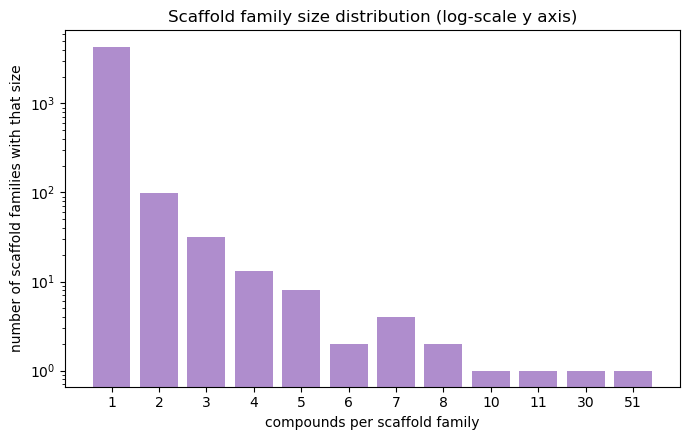

In [19]:
fig, ax = plt.subplots(figsize=(7, 4.5))
family_size_counts = scaffold_counts.value_counts().sort_index()
ax.bar(family_size_counts.index.astype(str), family_size_counts.values, color='tab:purple', alpha=0.75)
ax.set_xlabel('compounds per scaffold family')
ax.set_ylabel('number of scaffold families with that size')
ax.set_yscale('log')
ax.set_title('Scaffold family size distribution (log-scale y axis)')
plt.tight_layout()
plt.show()

**What this shows:** the training set is heavily fragmented at the scaffold level. Of
4,526 distinct Bemis-Murcko scaffolds, 96.4% (4,363) occur exactly once, together
accounting for 89.0% of all 4,905 compounds. Only 15 scaffolds have more than 10
members, and the two largest are generic, non-distinguishing building blocks (a bare
phenyl ring at 51 compounds; a phenyl-sulfonamide at 30) rather than a specific chemical
series — i.e. even the "largest families" aren't really cohesive chemical series in the
med-chem sense.

**Direct practical implication (not built here):** a scaffold-exact cluster split would,
for ~89% of compounds, put each one in its own singleton "cluster" — functionally
indistinguishable from a random split for the great majority of the dataset. Only the
small handful of larger families (the top ~15 scaffolds, roughly 2% of distinct
scaffolds) could be held out as a genuinely different distribution from train. A
similarity-based (not scaffold-exact) clustering approach would likely fare somewhat
better, given Section 1's evidence that most compounds do have *some* moderately similar
neighbour even without sharing an exact scaffold — but the achievable distributional
shift from *any* structure-based split on this dataset is likely to be modest, not
dramatic.

## 6. Final summary

| # | Question | Verdict |
|---|---|---|
| 1 | How diverse is the chemical space? | **Broadly diverse, low pairwise redundancy.** Mean pairwise Tanimoto ~0.13–0.14 in every isoform subset and overall; fewer than 0.12% of pairs in any isoform subset reach even 0.4 similarity. Apparent per-isoform NN differences (CYP3A4 highest, CYP2D6 lowest) are partly but not fully explained by subset-size differences. |
| 2 | Test→train NN similarity | **Test compounds are closer to train than train is to itself** on this metric (median max-Tanimoto 0.587 vs. 0.450, p≈1.3×10⁻²²⁵) — first measurement of this comparison, not a re-verification. Suggests NN-support loss under a cluster split may be less severe than the decomposition's premise assumes, with the caveat that the pooled figure under-represents CYP2D6 specifically. |
| 3 | Potency spread vs. CYP-specific structural determinants | **Weak-to-moderate correlations, matching prior literature.** Strongest is CYP2C9 vs. logD-proxy (r=0.47); CYP2D6/logP is essentially zero (r=0.002), matching Beck et al. (2021)'s reported null result for that isoform specifically. Not evidence of a data problem. |
| 4 | SAR discontinuity — activity cliffs | **Undersampled at the literature threshold (0.9); consistently above the PXR reference range (4–12%) at lower, better-sampled thresholds (14–45%).** 4 of the 7 pairs found at the 0.9 threshold are chirality artefacts, not genuine cliffs — confirmed via InChIKey block comparison. |
| 5 | Broad chemical series or fragmented space? | **Heavily fragmented.** 96.4% of Bemis-Murcko scaffolds are singletons, covering 89.0% of all compounds; the two largest families (51 and 30 compounds) are generic, non-distinguishing scaffolds, not real chemical series. |

**Feasibility of the planned cluster-based split, stated as a risk to flag, not
something routed around silently:** three independent pieces of evidence here point the
same direction. The chemical space is broadly diverse with very low pairwise redundancy
(Q1), scaffold structure is almost entirely singleton/fragmented rather than a few large
families (Q5), and the real blinded test set is already at least as close to train as
train is to itself (Q2). Together, these suggest a scaffold-exact cluster split would
functionally resemble a random split for the large majority of this dataset — there
simply aren't many large chemical families to hold out cleanly, and 89% of compounds
would end up as their own singleton "cluster." A similarity-based clustering approach
may do somewhat better, but the achievable distributional shift from *any*
structure-based split on this dataset is likely modest, not dramatic.

This is a genuine risk to the decomposition's design as currently scoped, not a reason
to abandon it: **the later notebook building the cluster split should measure and report
how much distributional shift the chosen split actually achieves relative to random**,
rather than assuming a cluster split guarantees a meaningfully different distribution on
this particular dataset. The Q4 finding (cliff prevalence well above the PXR range,
where measurable) cuts the other way to some extent — it suggests potency in this data
is locally sensitive to small structural changes more often than in the PXR comparison
case, which is exactly the kind of local structure a cluster split is meant to respect —
but that only matters if the split can actually separate compounds into meaningfully
different regions, which Q1/Q2/Q5 suggest may be harder here than assumed.

## Before finishing, check against CLAUDE.md

- **Row counts logged before/after every stage:** yes — Section 0 logs train/test shapes
  and per-isoform counts at load, re-confirmed against `01_data_curation.ipynb`. No
  filtering happens anywhere in this notebook (every table is either the full curated
  set or a non-null-pIC50 subset), so there is no "before/after a filter" delta to log
  beyond what's already shown.
- **Every modelling-adjacent decision not explicitly settled in the task brief was
  flagged and confirmed before proceeding, not silently picked:** three were surfaced —
  (1) the SALI similarity/cliff thresholds (adopted Tanimoto≥0.9 / ΔpIC50≥1 as primary,
  with 0.8 and 0.4 as labeled sensitivity checks after the 0.9 result came back
  near-empty); (2) the logD proxy (Crippen logP, explicitly labeled `logd_proxy`); (3)
  the `vsa_acc` proxy (PEOE_VSA1+PEOE_VSA2, explicitly labeled `vsa_acc_proxy`). All
  three are documented inline in Sections 3–4 where they're used, not buried in code.
- **Fingerprint/SALI logic lives in `src/features.py`, not duplicated inline:** yes —
  `ecfp4_fingerprints`, `pairwise_tanimoto_matrix`, `nearest_neighbor_similarity`,
  `compute_sali`, `isoform_structural_descriptors`, and `bemis_murcko_scaffold` are all
  defined there and imported in the setup cell, not redefined in this notebook.
- **No randomness without a logged seed:** no randomness is used anywhere in this
  notebook — every similarity, SALI, and scaffold computation is exhaustive over the
  actual dataset (no subsampling for plotting or visualization), confirmed rather than
  assumed. This rule doesn't apply here.
- **Markdown cell after each major output stating what it shows:** yes throughout —
  every plot and summary table in Sections 1–5 is followed by a markdown cell
  interpreting it.